# Wind Turbine Performance Evaluation — East Coast

Evaluate wind turbine energy production and cost across a configurable:
- **Temporal domain**: any contiguous range of years (2011–2020)
- **Spatial domain**: a single state, multiple states, or the full East Coast

The notebook loads per-year raw wind data files (`EastCoast_{year}_ws_only.npz`),
concatenates them, applies the spatial filter, and runs the standard
`GetCostAndGenerationWindTurbine` pipeline from `WindTurbineTools_EastCoast.py`.

**Output**: `.npz` file with turbine performance, named to reflect the years and region analyzed.

In [1]:
import numpy as np
import os
import time

os.chdir(r"C:\Users\rmiller9\Documents\East Coast Model")

from WindTurbineTools_EastCoast import GetCostAndGenerationWindTurbine
from GeneralGeoTools_EastCoast import PlotGeneralGeoData

## Configuration
Set the year range, spatial domain, and turbine to evaluate.

In [2]:
# ============================================================
# USER CONFIGURATION — edit this cell
# ============================================================

# --- Temporal domain ---
START_YEAR = 2016
END_YEAR   = 2018     # inclusive

# --- Spatial domain ---
# Set to a state name (e.g. "Florida", "North_Carolina") or "EastCoast" for all. Use _ for spaces in states with 2 words.
# Multiple states: use a list like ["Virginia", "Maryland", "Delaware"]
SPATIAL_DOMAIN = "North_Carolina"

# --- Turbine ---
# Options: ATB_8MW_2020_Vestas, Haliade150_6MW, ATB_12MW_2030, ATB_15MW_2030, ATB_18MW_2030
TURBINE_NAME = "ATB_8MW_2020_Vestas"

# --- Paths ---
INPUT_DATA_PATH = r"C:\Users\rmiller9\Documents\East Coast Model"
WIND_DATA_DIR   = r"C:\Users\rmiller9\Documents\East Coast Model\Resource Data\Wind\EastCoast"
TURBINE_PATH    = INPUT_DATA_PATH + "/Tech Designs/Wind/" + TURBINE_NAME
WIND_COST_PATH  = INPUT_DATA_PATH + "/Tech Designs/Wind/CostWindTurbines.xlsx"
GEO_DATA_PATH   = INPUT_DATA_PATH + "/Geospatial Data/CoastLine/"
OUTPUT_DIR      = INPUT_DATA_PATH + "/Tech Outputs/Wind"

# Wind speed keys in the .npz files
WIND_SPEED_HEIGHTS = {
    100: "windspeed_100m",
    140: "windspeed_140m",
    160: "windspeed_160m",
    200: "windspeed_200m"
}

# --- Derived ---
YEARS = list(range(START_YEAR, END_YEAR + 1))

# Build spatial label for output filename
if isinstance(SPATIAL_DOMAIN, list):
    SPATIAL_LABEL = "_".join(SPATIAL_DOMAIN)
else:
    SPATIAL_LABEL = SPATIAL_DOMAIN

# Build year label
if START_YEAR == END_YEAR:
    YEAR_LABEL = str(START_YEAR)
else:
    YEAR_LABEL = f"{START_YEAR}_{END_YEAR}"

SAVE_FILENAME = f"GenPU_{TURBINE_NAME}_{SPATIAL_LABEL}_{YEAR_LABEL}.npz"
SAVE_PATH = os.path.join(OUTPUT_DIR, SAVE_FILENAME)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Years:          {YEARS[0]}–{YEARS[-1]} ({len(YEARS)} years)")
print(f"Spatial domain: {SPATIAL_DOMAIN}")
print(f"Turbine:        {TURBINE_NAME}")
print(f"Output file:    {SAVE_FILENAME}")

Years:          2016–2018 (3 years)
Spatial domain: North_Carolina
Turbine:        ATB_8MW_2020_Vestas
Output file:    GenPU_ATB_8MW_2020_Vestas_North_Carolina_2016_2018.npz


## Load State Latitude Definitions
Read the state lat ranges from `State Lat Ranges.txt`.

In [3]:
# Load state latitude ranges
state_lat_ranges = {}
lat_ranges_path = os.path.join(INPUT_DATA_PATH, "State Lat Ranges.txt")

with open(lat_ranges_path, "r") as f:
    exec(f.read())  # defines state_lat_ranges dict

# Determine lat filter bounds
if SPATIAL_DOMAIN == "EastCoast":
    LAT_MIN = None
    LAT_MAX = None
    print("Spatial filter: NONE (full East Coast)")
elif isinstance(SPATIAL_DOMAIN, list):
    # Multiple states — take the union of their lat ranges
    lats = [state_lat_ranges[st] for st in SPATIAL_DOMAIN]
    LAT_MIN = min(lo for lo, hi in lats)
    LAT_MAX = max(hi for lo, hi in lats)
    print(f"Spatial filter: {SPATIAL_DOMAIN}")
    print(f"  Combined lat range: {LAT_MIN}° to {LAT_MAX}°")
else:
    # Single state
    LAT_MIN, LAT_MAX = state_lat_ranges[SPATIAL_DOMAIN]
    print(f"Spatial filter: {SPATIAL_DOMAIN}")
    print(f"  Lat range: {LAT_MIN}° to {LAT_MAX}°")

print()
print("Available states:")
for st, (lo, hi) in state_lat_ranges.items():
    print(f"  {st:20s}  {lo:.1f}° – {hi:.1f}°")

Spatial filter: North_Carolina
  Lat range: 33.7° to 36.6°

Available states:
  Florida               24.2° – 31.0°
  Georgia               30.6° – 32.2°
  South_Carolina        32.0° – 34.0°
  North_Carolina        33.7° – 36.6°
  Virginia              36.4° – 38.2°
  Maryland              38.0° – 38.6°
  Delaware              38.4° – 39.5°
  New_Jersey            38.8° – 41.0°
  New_York              40.4° – 41.5°
  Connecticut           41.2° – 41.5°
  Rhode_Island          41.1° – 41.5°
  Massachusetts         41.1° – 42.9°
  New_Hampshire         42.8° – 43.3°
  Maine                 43.0° – 45.5°


## Load and Prepare Wind Data
Load per-year `.npz` files, concatenate along the time axis, and apply spatial filter.

In [4]:
# ============================================================
# OPTIONAL: custom lat/long bounding box
# ------------------------------------------------------------
# Set CUSTOM_RANGE to a dict to restrict the run to an EXACT box, e.g.
#   CUSTOM_RANGE = {"lat_min": 37.0, "lat_max": 39.0, "lon_min": -75.6, "lon_max": -74.4}
# When set it OVERRIDES SPATIAL_DOMAIN and filters BOTH latitude and longitude
# (longitudes are negative on the East Coast). Leave as None to use
# SPATIAL_DOMAIN (state / list / "EastCoast") exactly as before.
CUSTOM_RANGE = None

if CUSTOM_RANGE is not None:
    LAT_MIN = CUSTOM_RANGE["lat_min"]
    LAT_MAX = CUSTOM_RANGE["lat_max"]
    LON_MIN = CUSTOM_RANGE["lon_min"]
    LON_MAX = CUSTOM_RANGE["lon_max"]
    SPATIAL_LABEL = "Box_%g_%g_%g_%g" % (LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)
    SAVE_FILENAME = f"GenPU_{TURBINE_NAME}_{SPATIAL_LABEL}_{YEAR_LABEL}.npz"
    SAVE_PATH = os.path.join(OUTPUT_DIR, SAVE_FILENAME)
    print(f"CUSTOM RANGE active: lat [{LAT_MIN}, {LAT_MAX}], lon [{LON_MIN}, {LON_MAX}]")
    print(f"  Output file: {SAVE_FILENAME}")
else:
    LON_MIN = None
    LON_MAX = None
    print("CUSTOM_RANGE not set - using SPATIAL_DOMAIN as configured.")


CUSTOM_RANGE not set - using SPATIAL_DOMAIN as configured.


In [5]:
t0 = time.time()

all_time = []
all_ws = {key: [] for key in WIND_SPEED_HEIGHTS.values()}
coords = None

for year in YEARS:
    fname = f"EastCoast_{year}_ws_only.npz"
    fpath = os.path.join(WIND_DATA_DIR, fname)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Missing wind data file: {fpath}")

    print(f"Loading {fname}...", end=" ")
    data = np.load(fpath, allow_pickle=True)

    all_time.append(data["time_index"])

    for key in WIND_SPEED_HEIGHTS.values():
        all_ws[key].append(data[key])

    if coords is None:
        coords = data["coordinates"]

    n_t = len(data["time_index"])
    n_s = data["coordinates"].shape[0]
    print(f"{n_t:,} timesteps, {n_s:,} sites")
    data.close()

# Concatenate along time axis
print("\nConcatenating...")
time_index = np.concatenate(all_time, axis=0)
wind_arrays = {}
for key in WIND_SPEED_HEIGHTS.values():
    wind_arrays[key] = np.concatenate(all_ws[key], axis=0)
del all_time, all_ws

print(f"  Combined: {len(time_index):,} timesteps x {coords.shape[0]:,} sites")

# --- Apply spatial filter ---
LON_MIN = globals().get('LON_MIN', None)
LON_MAX = globals().get('LON_MAX', None)
if LAT_MIN is not None and LAT_MAX is not None:
    lat = coords[:, 0]
    lon = coords[:, 1]
    spatial_mask = (lat >= LAT_MIN) & (lat <= LAT_MAX)
    if LON_MIN is not None and LON_MAX is not None:
        spatial_mask = spatial_mask & (lon >= LON_MIN) & (lon <= LON_MAX)
    n_before = coords.shape[0]
    coords = coords[spatial_mask]
    for key in wind_arrays:
        wind_arrays[key] = wind_arrays[key][:, spatial_mask]
    n_after = coords.shape[0]
    print(f"  Spatial filter: {n_before:,} -> {n_after:,} sites")
else:
    print(f"  No spatial filter applied.")

# --- Save combined/filtered file as temp input for WindTurbineTools ---
temp_file = os.path.join(OUTPUT_DIR, f"_temp_wind_{SPATIAL_LABEL}_{YEAR_LABEL}.npz")
save_dict = {"time_index": time_index, "coordinates": coords}
save_dict.update(wind_arrays)
np.savez(temp_file, **save_dict)

del wind_arrays, save_dict

temp_size_gb = os.path.getsize(temp_file) / (1024**3)
elapsed = time.time() - t0
print(f"\n  Temp file: {temp_size_gb:.2f} GB")
print(f"  Elapsed:   {elapsed:.0f}s")

Loading EastCoast_2016_ws_only.npz... 8,784 timesteps, 551,824 sites
Loading EastCoast_2017_ws_only.npz... 8,760 timesteps, 551,824 sites
Loading EastCoast_2018_ws_only.npz... 8,760 timesteps, 551,824 sites

Concatenating...
  Combined: 26,304 timesteps x 551,824 sites
  Spatial filter: 551,824 -> 73,162 sites

  Temp file: 28.68 GB
  Elapsed:   1563s


## Run Turbine Evaluation
Call `GetCostAndGenerationWindTurbine` with the combined data to compute
energy production, capacity factor, LCOE, and costs.

In [6]:
print(f"Running turbine evaluation: {TURBINE_NAME}")
print(f"  Data: {SPATIAL_LABEL}, {YEAR_LABEL}")
print(f"  Save: {SAVE_PATH}")
print()

t0 = time.time()

results = GetCostAndGenerationWindTurbine(
    InputDataPath=INPUT_DATA_PATH,
    WindCostPath=WIND_COST_PATH,
    WindTurbine=TURBINE_NAME,
    WindDataFile=temp_file,
    WindSpeedHeightsAvailable=WIND_SPEED_HEIGHTS,
    TurbinePath=TURBINE_PATH,
    SavePath=SAVE_PATH
)

(WindEnergy_pu, RatedPower, LatLong, WS_Hub, Depth, DistanceShore,
 TRG_site, CAPEX_site, OPEX_site, AnnualizedCost, TimeList, NumberOfCellsPerSite) = results

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.0f}s")
print(f"  Sites:       {LatLong.shape[0]:,}")
print(f"  Timesteps:   {WindEnergy_pu.shape[0]:,}")
print(f"  Mean CF:     {np.mean(WindEnergy_pu):.3f}")

# Calculate LCOE
cf = np.mean(WindEnergy_pu, axis=0)
lcoe = AnnualizedCost * 1e6 / (cf * RatedPower * 8760)
valid_lcoe = lcoe[np.isfinite(lcoe)]
print(f"  Median LCOE: ${np.median(valid_lcoe):.1f}/MWh")

# Clean up temp file
if os.path.exists(temp_file):
    os.remove(temp_file)
    print(f"\n  Cleaned up temp file.")

out_size_gb = os.path.getsize(SAVE_PATH) / (1024**3)
print(f"  Output:      {SAVE_FILENAME} ({out_size_gb:.2f} GB)")

Running turbine evaluation: ATB_8MW_2020_Vestas
  Data: North_Carolina, 2016_2018
  Save: C:\Users\rmiller9\Documents\East Coast Model/Tech Outputs/Wind\GenPU_ATB_8MW_2020_Vestas_North_Carolina_2016_2018.npz


 Calculating water depth at each point


100%|██████████| 7317/7317 [03:53<00:00, 31.37it/s]



 Calculating distance to shore for viable site locations


100%|██████████| 3659/3659 [00:59<00:00, 60.99it/s]



Done in 365s
  Sites:       8,833
  Timesteps:   26,304
  Mean CF:     0.483
  Median LCOE: $94.9/MWh

  Cleaned up temp file.
  Output:      GenPU_ATB_8MW_2020_Vestas_North_Carolina_2016_2018.npz (0.87 GB)


## Results Summary

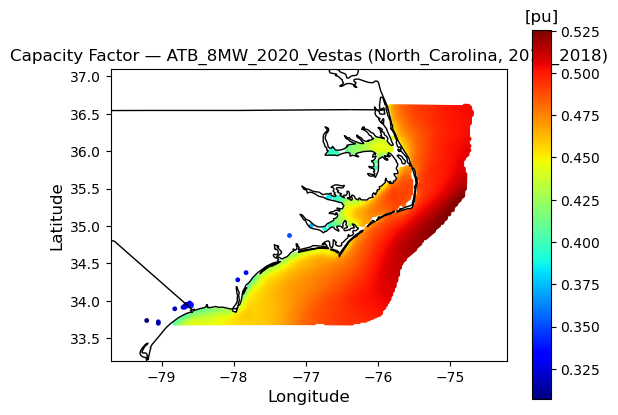

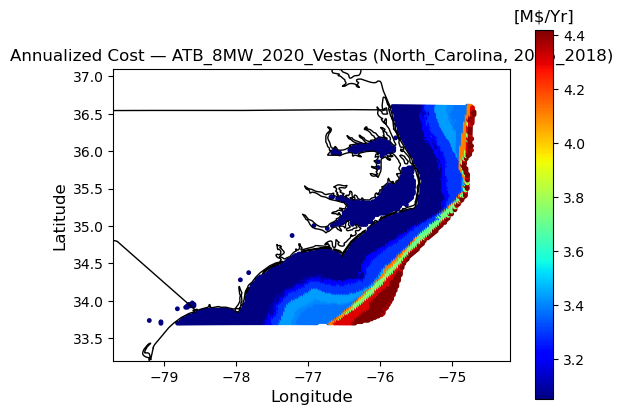

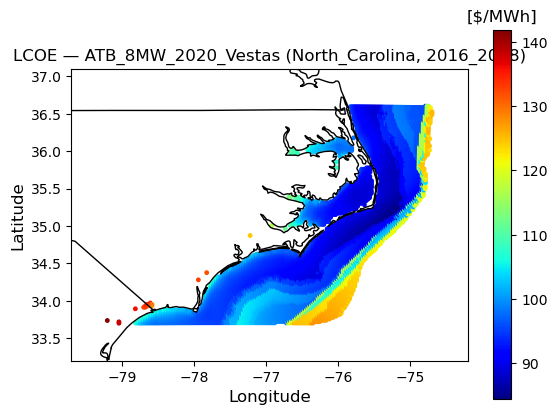

In [7]:
# Capacity factor map
PlotGeneralGeoData(
    LatLong, np.mean(WindEnergy_pu, axis=0), GEO_DATA_PATH,
    ColorBarTitle="[pu]",
    Title=f"Capacity Factor — {TURBINE_NAME} ({SPATIAL_LABEL}, {YEAR_LABEL})",
    SavePath=None, s=6
)

# Annualized cost map
PlotGeneralGeoData(
    LatLong, AnnualizedCost, GEO_DATA_PATH,
    ColorBarTitle="[M$/Yr]",
    Title=f"Annualized Cost — {TURBINE_NAME} ({SPATIAL_LABEL}, {YEAR_LABEL})",
    SavePath=None, s=6
)

# LCOE map
PlotGeneralGeoData(
    LatLong, lcoe, GEO_DATA_PATH,
    ColorBarTitle="[$/MWh]",
    Title=f"LCOE — {TURBINE_NAME} ({SPATIAL_LABEL}, {YEAR_LABEL})",
    SavePath=None, s=6
)

## Batch Run (Optional)
Run multiple turbines across the same temporal and spatial domain.

In [ ]:
# Uncomment and edit to run multiple turbines in sequence
# TURBINE_LIST = ["ATB_8MW_2020_Vestas", "ATB_12MW_2030", "ATB_15MW_2030", "ATB_18MW_2030"]
#
# for turbine in TURBINE_LIST:
#     turbine_path = INPUT_DATA_PATH + "/Tech Designs/Wind/" + turbine
#     save_path = os.path.join(OUTPUT_DIR, f"GenPU_{turbine}_{SPATIAL_LABEL}_{YEAR_LABEL}.npz")
#
#     if os.path.exists(save_path):
#         print(f"[SKIP] {turbine} — already exists")
#         continue
#
#     print(f"Processing {turbine}...")
#     _ = GetCostAndGenerationWindTurbine(
#         INPUT_DATA_PATH, WIND_COST_PATH, turbine, temp_file,
#         WIND_SPEED_HEIGHTS, TurbinePath=turbine_path, SavePath=save_path)
#     print(f"  Saved: {os.path.basename(save_path)}")